In [1]:
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv(r"C:\Users\Yilinzhao\Documents\Data_Science\data-science-projects\linear-regression\boston-housing-regression\data\boston_housing_data.csv")
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PIRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [2]:
import os
print(os.getcwd())

C:\Users\Yilinzhao\Documents\Data_Science\data-science-projects\linear-regression\boston-housing-regression\notebook


In [3]:
X = df.drop(columns='MEDV')
y = df['MEDV']
X
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

In [4]:
print(df.isnull().sum())

CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM          0
AGE         0
DIS         0
RAD         0
TAX         0
PIRATIO     0
B           0
LSTAT       0
MEDV       54
dtype: int64


In [5]:
print(df['MEDV'].fillna(0,inplace=True))
print(df.isnull().sum())

None
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PIRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [6]:
line1=LinearRegression()
#todo:3. Divide the dataset: training set and test set
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)
# fitting
line1.fit(X_train,y_train)
print("weight: ",line1.coef_)
print("intercetp: ",line1.intercept_)
#todo:forecast
Y=line1.predict(X_test)
print("value of prediction", Y)
print("value of reality: ", y_test)

weight:  [ 9.88237104e-02  1.05839943e-01 -2.01410059e-01  3.51665247e+00
 -4.09361357e-02  9.12071023e-02  8.11631556e-03 -1.83175021e+00
 -9.69917681e-04 -9.09748299e-03  1.42893722e-03  5.99551785e-03
 -8.36947556e-01]
intercetp:  41.1582170934084
value of prediction [ 23.87356821  25.80212168  28.11695004   3.00896754  18.77129516
  24.82528084  19.8540411   24.89283249  24.32678439  23.79944152
   2.3434669   -4.97597062  16.63318375   1.63477003  35.73712609
  29.5098366   20.22609567  32.84769292  30.66540807  26.13320192
  26.12767227  22.73763417  23.85184523  31.43058183  22.95232717
  -9.58975458  21.51104832  20.44319832  31.88927061  19.96998191
  -2.54320917  18.44064543  19.54168924  22.08801471  28.88234249
  22.98819942   5.64848046  29.61321032  15.52900982  11.02371621
  21.56188373  19.66185525  21.26432859  15.98171601  21.64148701
  24.39710416  14.28499366  24.58894217  10.44456571  26.61568576
  23.38572517  18.91705292  24.05701315  23.2670169   16.98534804
  1

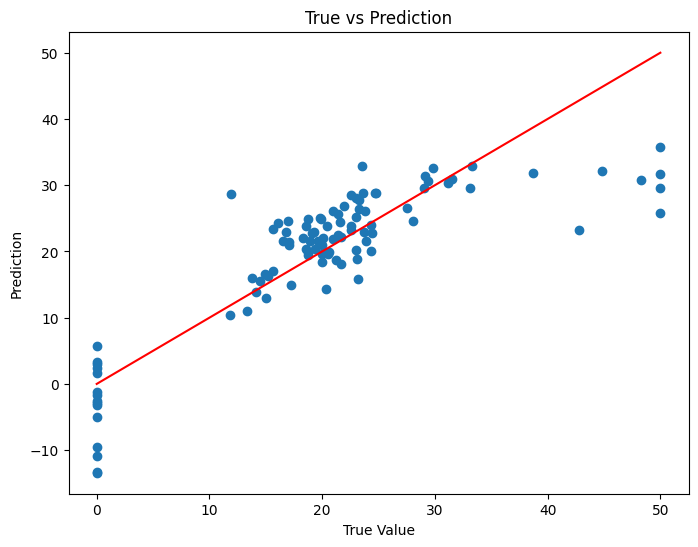

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, Y)

plt.xlabel("True Value")
plt.ylabel("Prediction")
plt.title("True vs Prediction")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.savefig('result.png', dpi=300, bbox_inches='tight')

plt.show()